# Sensitivity Analysis of template project

In [1]:
from uq_physicell.model_analysis import calculate_qoi_statistics
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings for cleaner output

db_file = 'Simulations.db'
qoi_funcs = {
    'live_cell_count': lambda df: len( df[ df['dead'] == False ]),
    'dead_cell_count': lambda df: len( df[ df['dead'] == True ]),
    'sum_dead_cell_count': lambda mcds_ts: sum(map(lambda mcds: len(mcds.get_cell_df()[mcds.get_cell_df()['dead'] == True]), mcds_ts))     
}

# Calculate the QoIs based on the qoi_funcs define (retunr summary based on mean across replicates and relative Monte Carlo standard error: sigma/[mean*sqrt(num_replicates)])
df_mean_qois, df_mean_std, df_relative_mcse = calculate_qoi_statistics(db_file, qoi_funcs)
display(df_mean_qois)

No QoI data provided, calculating QoIs from the database...
All samples in Samples table have corresponding entries in Output table.
Calculating QoIs from mcds list...


dead_cell_count  live_cell_count  sum_dead_cell_count
SampleID time                                                         
0        0.0                 0.0            511.0                  NaN
         240.0               6.8            582.6                  NaN
         480.0              13.2            632.4                  NaN
         720.0              15.6            673.6                  NaN
         960.0              18.0            712.0                  NaN
...                          ...              ...                  ...
47       6240.0             44.0           1869.4                  NaN
         6480.0             48.4           1933.4                  NaN
         6720.0             45.2           2004.6                  NaN
         6960.0             47.2           2078.8                  NaN
         7200.0             50.6           2147.0                859.4

[1488 rows x 3 columns]

## Plot the summary stats and relative Monte Carlo Standard Error (MCSE)

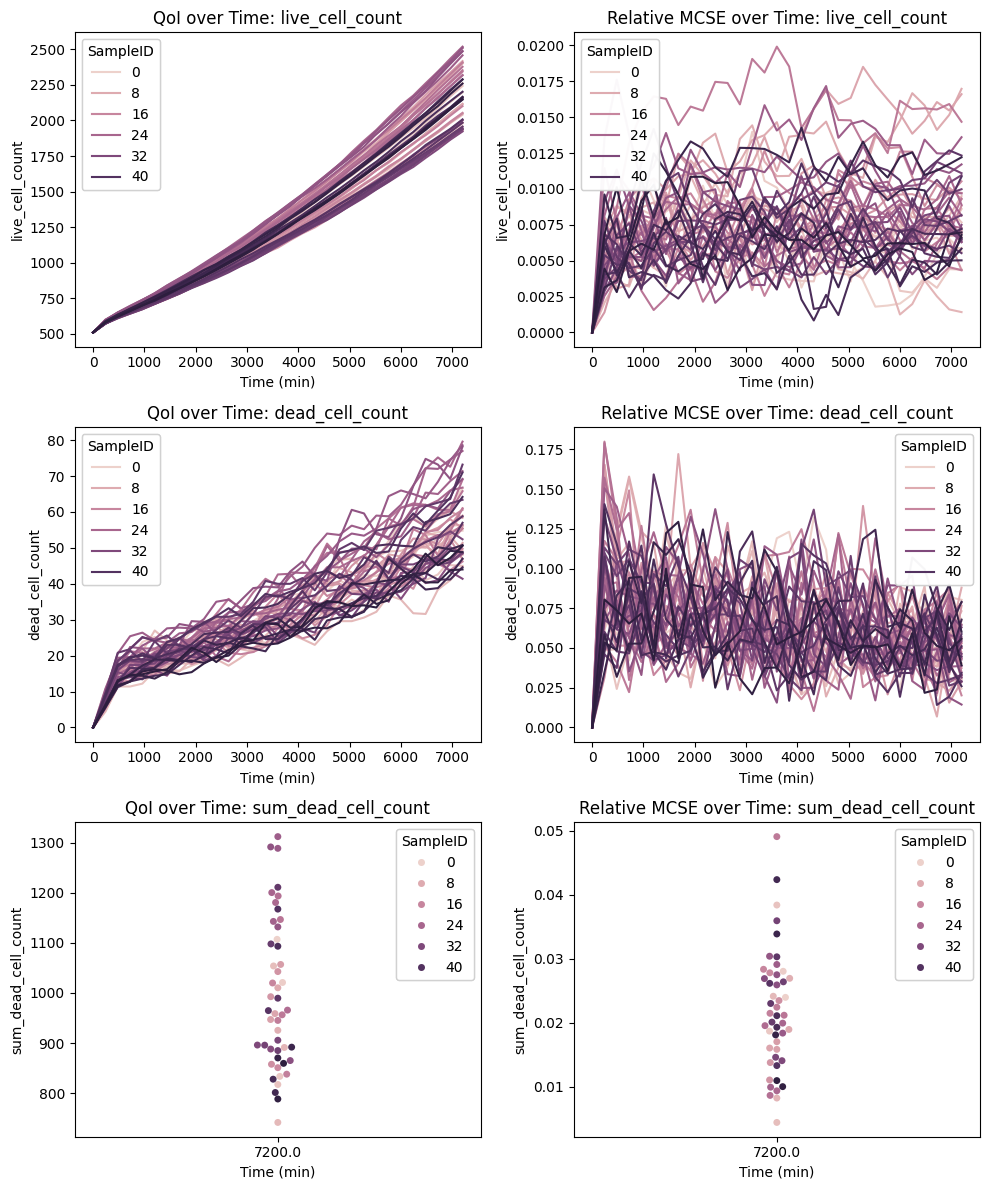

In [2]:
import matplotlib.pyplot as plt
from uq_physicell.model_analysis import plot_qoi_over_time

fig, axes = plt.subplots(len(qoi_funcs.keys()), 2, figsize=(10, 4*len(qoi_funcs.keys())))
for ax_id, qoi_name in enumerate(qoi_funcs.keys()):
     # Plot QoI time series
    plot_qoi_over_time(df_mean_qois, qoi_name, axes[ax_id,0])
    axes[ax_id,0].set_title(f"QoI over Time: {qoi_name}")
    # Plot mcse
    plot_qoi_over_time(df_relative_mcse, qoi_name, axes[ax_id,1])
    axes[ax_id,1].set_title(f"Relative MCSE over Time: {qoi_name}")

# Ensure proper layout and save the figure
plt.tight_layout()  # This will automatically adjust spacing to prevent overlaps
plt.savefig('QoI_TimeSeries_and_MCSE.svg', format='svg')

## Sensitivity Analysis from `cell_cycle_entry` and `apoptosis_rate` relative to population of live and dead cells.

Running sensitivity analysis with method: Sobol Sensitivity Analysis
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 0.0
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 240.0
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 480.0
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 720.0
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 960.0
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 1200.0
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 1440.0
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 1680.0
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 1920.0
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 2160.0
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 2400.0
Running Sobol Sensitivity Analysis for QoI: live_cell_count and time: 2640.0
Running Sobol 

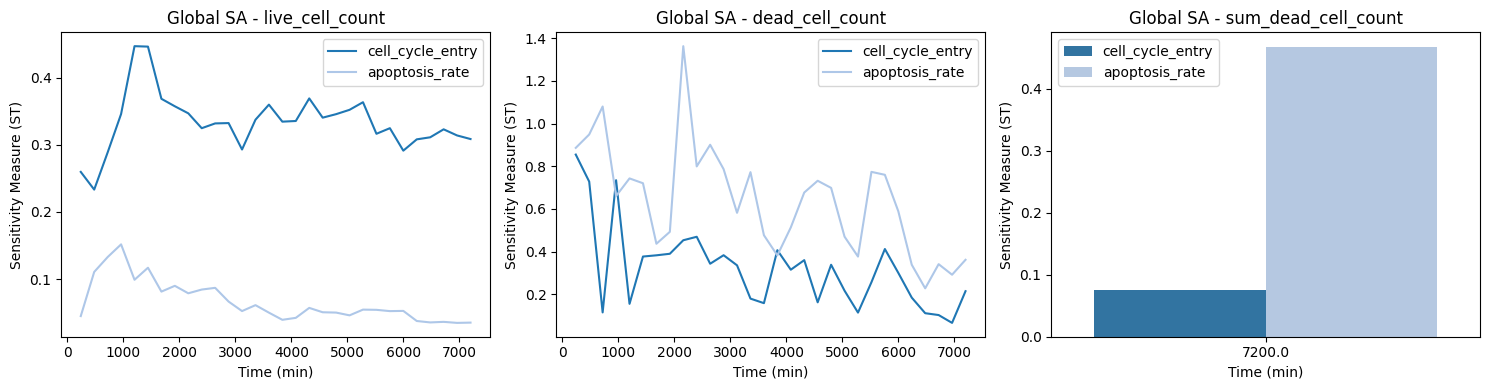

In [3]:
from uq_physicell.model_analysis import get_sa_results, plot_global_sa_results

sa_method = "Sobol Sensitivity Analysis"
qoi_names = list(qoi_funcs.keys())
sa_results, qoi_time_values = get_sa_results(db_file, qoi_names, df_mean_qois, sa_method)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax_id, qoi_name in enumerate(qoi_funcs.keys()):
    plot_global_sa_results(['cell_cycle_entry', 'apoptosis_rate'], sa_method, qoi_time_values, sa_results, qoi_name, 'ST' , axes[ax_id])
    axes[ax_id].set_title(f'Global SA - {qoi_name}')
    axes[ax_id].legend(loc='best')
plt.tight_layout() # This will automatically adjust spacing to prevent overlaps
plt.savefig('Global_SA_Results.svg', format='svg')

## Plot snapshots of some samples

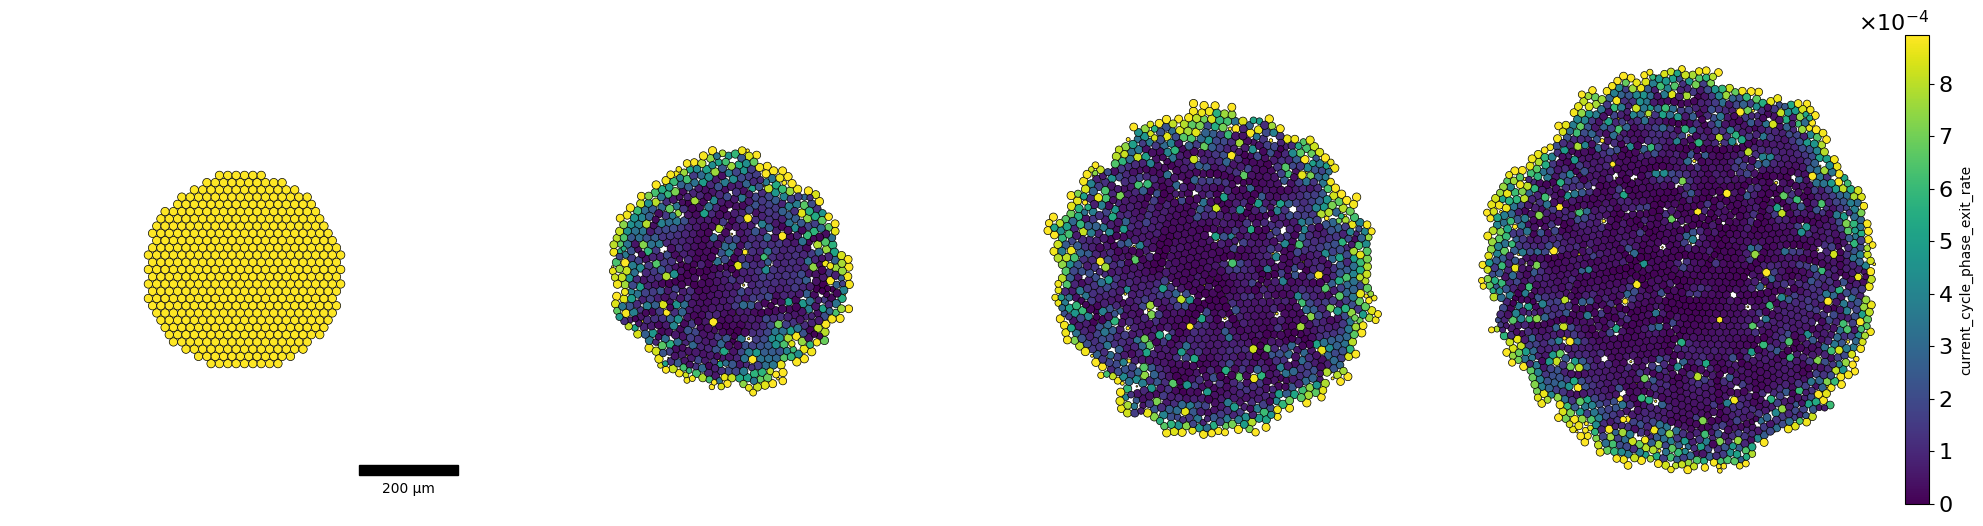

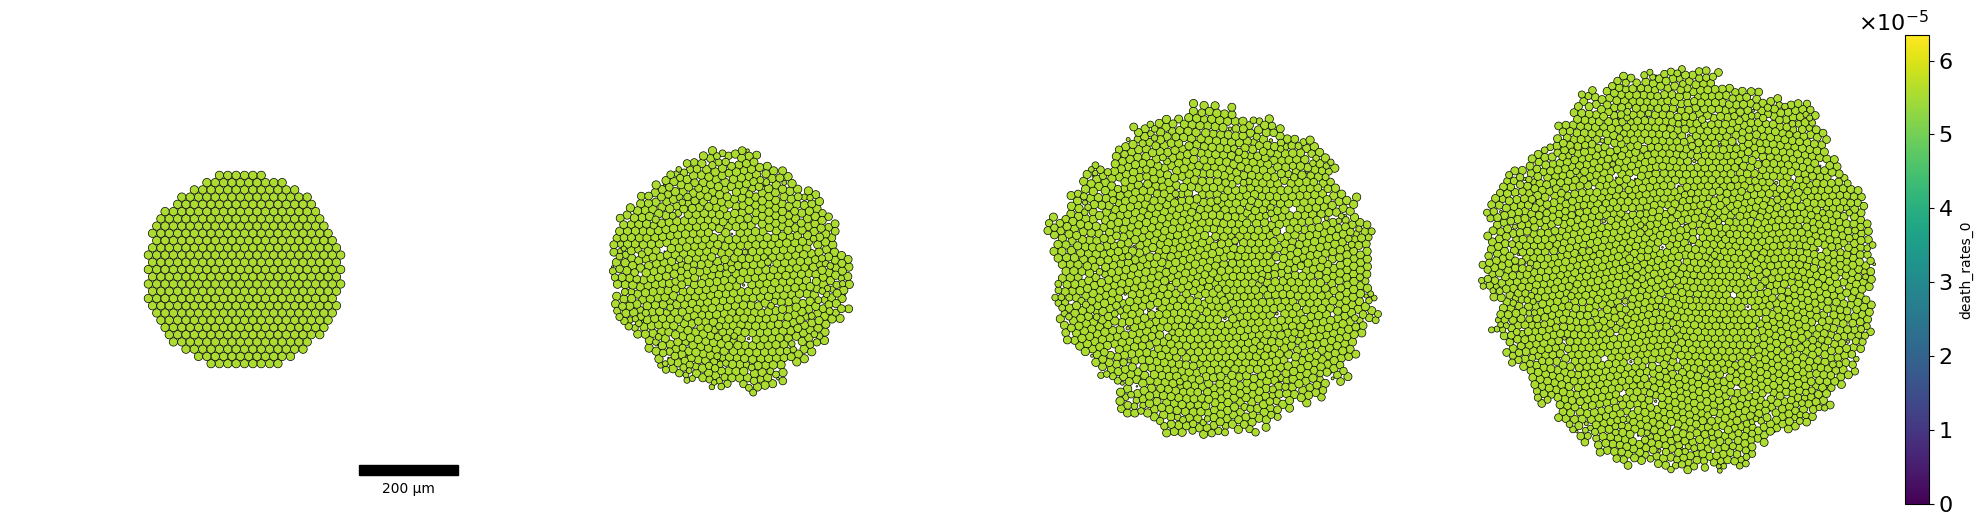

In [4]:
from uq_physicell.model_analysis import load_output, plot_cells_2D, load_samples
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

def plot_snapshots(sample_id, replicate_id, feature, min_value=0, max_value=1):
    df_qois_data_selected = load_output(db_file, sample_ids=[int(sample_id)], replicate_ids=[replicate_id], load_data=True)
    mcds_ts = df_qois_data_selected[df_qois_data_selected['SampleID'] == sample_id].iloc[0]['Data']
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True)
    ax_id = 0
    last_collection = None
    for i, mcds in enumerate(mcds_ts):
        if mcds.get_time() in [0,1440,4320,7200]: # Plot at specific time points
            df_cell = mcds.get_cell_df()
            last_collection = plot_cells_2D(df_cell, ax=axes[ax_id], scale_bar=True if (ax_id==0) else False, feature=feature, cmap='viridis', vmin=min_value, vmax=max_value)
            ax_id += 1
    cbar = fig.colorbar(last_collection, ax=axes[-1], fraction=0.05, pad=0.02)
    # Configure the formatter to use scientific notation
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2)) # Adjusts when sci-notation kicks in
    cbar.ax.tick_params(labelsize=16)               # tick labels
    cbar.ax.yaxis.get_offset_text().set_size(16)    # scientific notation text (e.g., ×10⁻³)
    cbar.ax.yaxis.set_major_formatter(formatter)
    cbar.set_label(feature)
    plt.tight_layout()
    plt.savefig(f'snapshot_{feature}_sample{sample_id}_replicate{replicate_id}.svg', format='svg')

# Identify the sample IDs with the maximum and minimum values for live and dead cell counts
max_live_cell_sample_id, _ = df_mean_qois['live_cell_count'].idxmax()
min_live_cell_sample_id, _ = df_mean_qois['live_cell_count'].idxmin()
max_dead_cell_sample_id, _ = df_mean_qois['sum_dead_cell_count'].idxmax()
min_dead_cell_sample_id, _ = df_mean_qois['sum_dead_cell_count'].idxmin()

# Extract parameters for the cmap limits
all_parameters = load_samples(db_file)
df_all_parameters = pd.DataFrame.from_dict(all_parameters, orient='index')
max_apoptosis_rate = df_all_parameters['apoptosis_rate'].max()
min_cell_cycle_entry = df_all_parameters['cell_cycle_entry'].min()

# Plot snapshots for the identified sample IDs and features of interest
plot_snapshots(max_live_cell_sample_id, replicate_id=0, feature='current_cycle_phase_exit_rate', max_value=1/min_cell_cycle_entry)
plot_snapshots(max_live_cell_sample_id, replicate_id=0, feature='death_rates_0', max_value=max_apoptosis_rate)
# plot_snapshots(min_live_cell_sample_id, replicate_id=0, feature='current_cycle_phase_exit_rate', max_value=1/min_cell_cycle_entry)
# plot_snapshots(max_dead_cell_sample_id, replicate_id=0, feature='death_rates_0', max_value=max_apoptosis_rate)
# plot_snapshots(min_dead_cell_sample_id, replicate_id=0, feature='death_rates_0', max_value=max_apoptosis_rate)